# House Price Prediction in Tehran 

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from itertools import combinations
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load dataset and initial inspection

In [3]:
CSV_PATH = "housePrice.csv"
assert Path(CSV_PATH).exists()
df = pd.read_csv(CSV_PATH)


In [4]:
print("My DataFrame:", df.shape)
print(df.dtypes)
display(df.head(10))
df.columns = [c.strip().replace("\ufeff","") for c in df.columns]


My DataFrame: (3479, 8)
Area           object
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price         float64
Price(USD)    float64
dtype: object


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
5,70,2,True,True,False,North Program Organization,2.050000e+09,68333.33
6,87,2,True,True,True,Pardis,6.000000e+08,20000.00
7,59,1,True,True,True,Shahran,2.150000e+09,71666.67
8,54,2,True,True,False,Andisheh,4.930000e+08,16433.33
9,71,1,True,True,True,West Ferdows Boulevard,2.370000e+09,79000.00


## Data Cleaning

### Remove entries without address

In [5]:
df["Address"] = df["Address"].astype(str).str.strip()
df.replace({"Address": {"": np.nan, "nan": np.nan}}, inplace=True)
before = df.shape[0]
df = df.dropna(subset=["Address"])
print(f" {before - df.shape[0]} rows with missing address were removedد.")


 23 rows with missing address were removedد.


### Remove invalid area values

In [6]:
df["Area"] = pd.to_numeric(df["Area"], errors="coerce")
before = df.shape[0]
df = df.dropna(subset=["Area"])
print(f"rows with non-numeric area were removed:  {before - df.shape[0]} :ردیف حذف شد.")


q99 = df["Area"].quantile(0.99)
area_cut = max(400, q99) 
before = df.shape[0]
df = df[(df["Area"] > 15) & (df["Area"] <= area_cut)]
print(f" {before - df.shape[0]}rows with unrealistic area were removed ≤ {area_cut:.0f} m)")

rows with non-numeric area were removed:  6 :ردیف حذف شد.
 31rows with unrealistic area were removed ≤ 400 m)


### Remove outliers in price

In [7]:

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
before = df.shape[0]
df = df.dropna(subset=["Price"])
print(f"rows with non-numeric price were removed: {before - df.shape[0]}.")

q99_price = df["Price"].quantile(0.99)
price_cut = max(1e9, q99_price)  
before = df.shape[0]
df = df[(df["Price"] > 1e6) & (df["Price"] <= price_cut)]
print(f"{before - df.shape[0]}  rows with unrealistic price were removed.≤ {price_cut:,.0f} toman)")




rows with non-numeric price were removed: 0.
35  rows with unrealistic price were removed.≤ 36,410,000,000 toman)


### If price is in USD

In [8]:
if "Price(USD)" in df.columns:
    df["Price(USD)"] = pd.to_numeric(df["Price(USD)"], errors="coerce")
    before = df.shape[0]
    df = df.dropna(subset=["Price(USD)"])
    print(f"rows with non-numeric USD price were removed.: {before - df.shape[0]} .")

    q99_usd = df["Price(USD)"].quantile(0.99)
    usd_cut = max(1e4, q99_usd)
    before = df.shape[0]
    df = df[(df["Price(USD)"] > 100) & (df["Price(USD)"] <= usd_cut)]
    print(f"{before - df.shape[0]} rows with unrealistic USD price were removed.: ≤ {usd_cut:,.0f} USD)")


rows with non-numeric USD price were removed.: 0 .
34 rows with unrealistic USD price were removed.: ≤ 970,633 USD)


### Convert boolean columns to 0/1


In [9]:
bool_cols = ["Parking", "Warehouse", "Elevator"]
for c in bool_cols:
    if df[c].dtype == bool or df[c].dtype == object:
        df[c] = df[c].map({True:1, False:0, "True":1, "False":0}).astype("Int64")

In [10]:
print("Final dataset shape after cleaning:", df.shape)

display(df.describe(include="all"))

Final dataset shape after cleaning: (3350, 8)


,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
count,3350.000000,3350.000000,3350.000000,3350.000000,3350.000000,3350,3.350000e+03,3350.000000
unique,NaN,NaN,NaN,NaN,NaN,189,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,Punak,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,161,NaN,NaN
mean,98.971642,2.038507,0.843881,0.914328,0.791045,NaN,4.400005e+09,146666.825937
std,44.018829,0.709958,0.363023,0.279920,0.406623,NaN,4.657568e+09,155252.261624
min,30.000000,0.000000,0.000000,0.000000,0.000000,NaN,3.600000e+06,120.000000
25%,68.000000,2.000000,1.000000,1.000000,1.000000,NaN,1.380000e+09,46000.000000
50%,90.000000,2.000000,1.000000,1.000000,1.000000,NaN,2.750000e+09,91666.670000
75%,117.000000,2.000000,1.000000,1.000000,1.000000,NaN,5.600000e+09,186666.670000


## Exploratory Data Analysis (EDA)

###  Scatter: Price vs Area

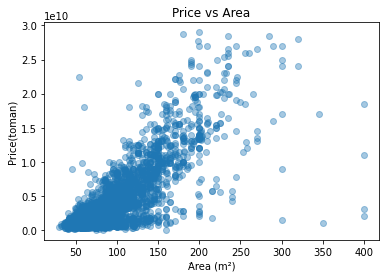

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["Area"], df["Price"],alpha=0.4)
plt.xlabel("َArea (m²)")
plt.ylabel("Price(toman)")
plt.title("Price vs Area")
plt.show()


### Boxplot: Price vs Room

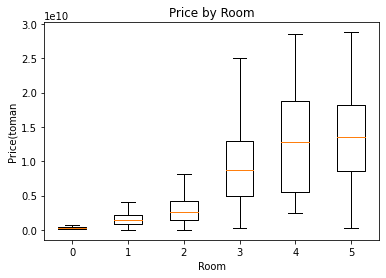

In [12]:
plt.figure(figsize=(6,4))
rooms_sorted = sorted(df["Room"].dropna().unique())
data = [df[df["Room"]==r]["Price"] for r in rooms_sorted]
plt.boxplot(data, labels=rooms_sorted, showfliers=False)
plt.xlabel("Room")
plt.ylabel("Price(toman")
plt.title("Price by Room")
plt.show()


### Top address vs Price

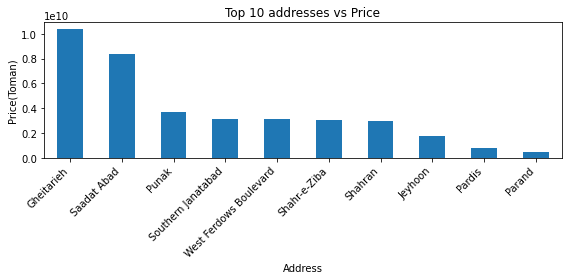

In [13]:
top_addresses = df["Address"].value_counts().head(10).index
addr_stats = (df[df["Address"].isin(top_addresses)]
              .groupby("Address")["Price"].mean().sort_values(ascending=False))
plt.figure(figsize=(8,4))
addr_stats.plot(kind="bar")
plt.ylabel("Price(Toman)")
plt.title("Top 10 addresses vs Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

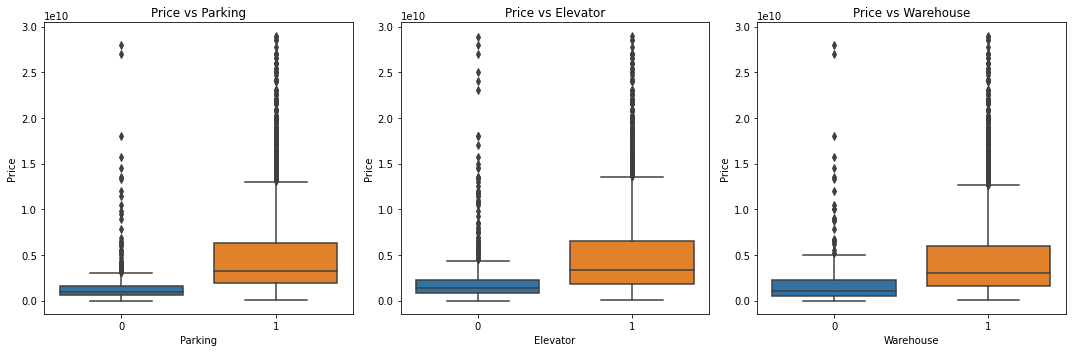

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


bool_cols = ["Parking", "Elevator", "Warehouse"]

plt.figure(figsize=(15, 5))

for i, col in enumerate(bool_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col], y=df["Price"])
    plt.title(f"Price vs {col}")
    plt.xlabel(col)
    plt.ylabel("Price")

plt.tight_layout()
plt.show()


## Model Definition

### Feature selection

In [15]:
bool_features = ["Parking", "Warehouse", "Elevator"]
df[bool_features] = df[bool_features].astype(int)
numeric_features = ["Area", "Room"]





In [16]:
X = df[numeric_features + bool_features]
y = df["Price(USD)"].values

### Feature scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train-test split

In [18]:

 
msk = np.random.rand(len(df)) < 0.8 
X_train = X_scaled[msk]    
X_test  = X_scaled[~msk]
y_train = y[msk]
y_test  = y[~msk]

####   Ridge Regression 

In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)  # alpha=1.0 
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
r2_test = r2_score(y_test, y_pred)

#### Cross-Validation

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(ridge, X_scaled, y, cv=5, scoring="r2")
mean_cv_r2 = np.mean(cv_scores)

## Results

In [23]:
print("R² on test data:", r2_test)
print("mean R² with 5-fold CV:", mean_cv_r2)

R² on test data: 0.5999757543714604
mean R² with 5-fold CV: 0.5634419861058925


## Visualization: Predictions vs Real values


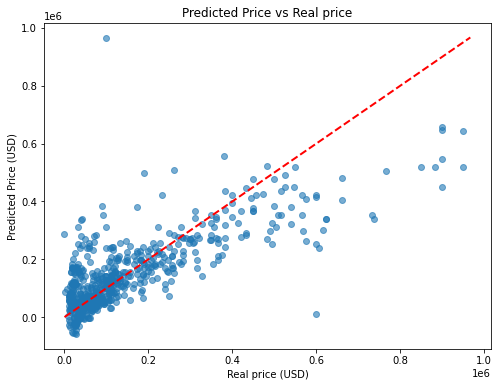

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Real price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Predicted Price vs Real price")
plt.show()